# 📈 Notebook 3 — Frequency Models

**Goal:** Fit all frequency models, show comparison metrics, and **you decide which model to use.**

| Model | Why use it |
|---|---|
| **Poisson GLM** | Industry standard. Log link = multiplicative rating factors. |
| **Negative Binomial GLM** | Absorbs overdispersion (variance > mean in claim counts). |
| **XGBoost** | Captures non-linear interactions. Benchmark against GLMs. |

**Input:** `outputs/df_clean.parquet` · `outputs/meta.json`

**Output:** `outputs/freq_model.pkl` · `outputs/df_with_freq.parquet` · `outputs/frequency_results.json`

---

## 3.1 — Load & Encode

In [1]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
import matplotlib.pyplot as plt
import json, pickle, warnings
warnings.filterwarnings('ignore')

df   = pd.read_parquet('../outputs/df_clean.parquet')
meta = json.load(open('../outputs/meta.json'))

CLAIM_COUNT_COL = meta['claim_count_col']
EXPOSURE_COL    = meta['exposure_col']
NUM_COLS        = meta['num_cols']
CAT_COLS        = meta['cat_cols']

def tool_prepare_frequency_features(df, num_cols, cat_cols, claim_count_col, exposure_col):
    """
    Preprocesses and encodes frequency features for modeling.
    
    What this tool does:
        Imputes numeric features with training medians, one-hot encodes categorical
        predictors with drop_first=True to avoid collinearity, and extracts targets.
        
    Returns:
        tuple: (X_encoded, y_claim_counts, exposure_durations, feature_names)
    """
    df_enc = df[num_cols + cat_cols].copy()
    for col in num_cols:
        df_enc[col] = df_enc[col].fillna(df_enc[col].median())
        
    df_enc = pd.get_dummies(df_enc, columns=cat_cols, drop_first=True, dtype=float)
    feature_names = list(df_enc.columns)
    
    y = df[claim_count_col].values.astype(float)
    exposure = np.clip(df[exposure_col].values.astype(float), 1e-12, None)
    
    return df_enc, y, exposure, feature_names

# ── Run Execution ─────────────────────────────────────────────────────────────
X, y, exposure, FEATURE_COLS = tool_prepare_frequency_features(
    df, NUM_COLS, CAT_COLS, CLAIM_COUNT_COL, EXPOSURE_COL
)

print(f'Training policies: {len(X):,}')
print(f'Encoded features : {len(FEATURE_COLS)}  ({len(NUM_COLS)} num + {len(FEATURE_COLS)-len(NUM_COLS)} dummy)')
print(f'Target claims    : {y.sum():,.0f} total claims on {exposure.sum():,.1f} exposure years')
print(f'Portfolio freq   : {y.sum()/exposure.sum():.4f} claims/year')


Training policies: 111,615
Encoded features : 31  (4 num + 27 dummy)
Target claims    : 5,647 total claims on 111,615.0 exposure years
Portfolio freq   : 0.0506 claims/year


## 3.2 — Train/Validation Split (80/20)

In [2]:
from sklearn.model_selection import train_test_split

y_bin = (y > 0).astype(int)
X_tr, X_val, y_tr, y_val, exp_tr, exp_val = train_test_split(
    X, y, exposure, test_size=0.2, random_state=42, stratify=y_bin)

off_tr  = np.log(np.clip(exp_tr,  1e-12, None))
off_val = np.log(np.clip(exp_val, 1e-12, None))

X_tr_sm  = sm.add_constant(X_tr.to_numpy(dtype=float))
X_val_sm = sm.add_constant(X_val.to_numpy(dtype=float))

print(f'Train: {len(X_tr):,}   Val: {len(X_val):,}')

Train: 89,292   Val: 22,323


## 3.3 — Model A: Poisson GLM

In [3]:
def tool_fit_poisson_glm(X_tr_sm, y_tr, off_tr, X_val_sm, off_val):
    """
    Estimates a Poisson Generalized Linear Model with log-exposure offset.
    
    What this tool does:
        Fits log-link Poisson GLM using iteratively reweighted least squares (IRLS)
        under the assumption Var(Y) = mu.
        
    Returns:
        tuple: (fitted_model, pred_train, pred_val)
    """
    model = sm.GLM(
        y_tr, X_tr_sm,
        family=sm.families.Poisson(link=sm.families.links.Log()),
        offset=off_tr
    ).fit(maxiter=100)
    
    pred_tr  = model.predict(X_tr_sm,  offset=off_tr)
    pred_val = model.predict(X_val_sm, offset=off_val)
    return model, pred_tr, pred_val

# ── Run Execution ─────────────────────────────────────────────────────────────
print('Fitting Poisson GLM...')
pois, pred_pois_tr, pred_pois_val = tool_fit_poisson_glm(X_tr_sm, y_tr, off_tr, X_val_sm, off_val)
print(f'Poisson GLM | AIC: {pois.aic:.1f} | Deviance: {pois.deviance:.1f}')


Fitting Poisson GLM...
Poisson GLM | AIC: 35843.1 | Deviance: 27008.5


## 3.4 — Model B: Negative Binomial GLM

In [4]:
def tool_fit_negative_binomial_glm(X_tr_sm, y_tr, off_tr, X_val_sm, off_val):
    """
    Estimates a Negative Binomial GLM to account for claim overdispersion.
    
    What this tool does:
        Fits NB2 distribution with Var(Y) = mu + alpha * mu^2, relaxing the equi-dispersion constraint.
        
    Returns:
        tuple: (fitted_model, pred_train, pred_val)
    """
    model = sm.GLM(
        y_tr, X_tr_sm,
        family=sm.families.NegativeBinomial(),
        offset=off_tr
    ).fit(maxiter=100)
    
    pred_tr  = model.predict(X_tr_sm,  offset=off_tr)
    pred_val = model.predict(X_val_sm, offset=off_val)
    return model, pred_tr, pred_val

# ── Run Execution ─────────────────────────────────────────────────────────────
print('Fitting Negative Binomial GLM...')
nb, pred_nb_tr, pred_nb_val = tool_fit_negative_binomial_glm(X_tr_sm, y_tr, off_tr, X_val_sm, off_val)
print(f'NegBinomial | AIC: {nb.aic:.1f} | Deviance: {nb.deviance:.1f}')


Fitting Negative Binomial GLM...
NegBinomial | AIC: 35835.0 | Deviance: 23577.0


## 3.5 — Model C: XGBoost

In [5]:
def tool_fit_frequency_xgboost(X_tr, y_tr, exp_tr, X_val, y_val, exp_val):
    """
    Trains an XGBoost regressor under a Poisson objective with log(exposure) base margins.
    
    What this tool does:
        Non-linear gradient boosted tree benchmark capturing complex interactions and thresholds.
        
    Returns:
        tuple: (fitted_xgb_model, pred_train, pred_val)
    """
    try:
        from xgboost import XGBRegressor
        xgb = XGBRegressor(
            objective='count:poisson', n_estimators=300,
            learning_rate=0.05, max_depth=4,
            subsample=0.8, colsample_bytree=0.8,
            random_state=42, verbosity=0
        )
        bm_tr  = np.log(np.clip(exp_tr,  1e-12, None))
        bm_val = np.log(np.clip(exp_val, 1e-12, None))
        
        xgb.fit(X_tr, y_tr, base_margin=bm_tr, eval_set=[(X_val, y_val)], verbose=False)
        pred_tr  = xgb.predict(X_tr,  base_margin=bm_tr)
        pred_val = xgb.predict(X_val, base_margin=bm_val)
        return xgb, pred_tr, pred_val
    except ImportError:
        return None, None, None

# ── Run Execution ─────────────────────────────────────────────────────────────
xgb, pred_xgb_tr, pred_xgb_val = tool_fit_frequency_xgboost(
    X_tr, y_tr, exp_tr, X_val, y_val, exp_val
)
HAS_XGB = xgb is not None
if HAS_XGB:
    print('XGBoost fitted successfully.')
else:
    print('⚠ XGBoost not available')


XGBoost fitted successfully.


## 3.6 — Comparison Table

In [6]:
from sklearn.metrics import auc, mean_absolute_error, mean_squared_error

def gini_coeff(y_true, y_pred):
    """
    Calculates the Actuarial Gini coefficient (Lorenz curve AUC).
    Gini = 2 * (AUC - 0.5)
    """
    df_g = pd.DataFrame({'y': y_true, 'p': y_pred}).sort_values('p', ascending=False)
    cum_pop = np.linspace(0, 1, len(df_g) + 1)
    cum_loss = np.concatenate([[0], df_g['y'].cumsum().values / df_g['y'].sum()])
    return round(float(2.0 * (auc(cum_pop, cum_loss) - 0.5)), 4)

def tool_evaluate_frequency_models(candidates_dict, y_val):
    """
    Evaluates frequency models on validation metrics, Gini lift, and goodness of fit.
    
    What this tool does:
        Calculates Actuarial Gini coefficient (Lorenz AUC): Gini = 2 * (AUC - 0.5),
        alongside MAE, RMSE, AIC, and Deviance to compile the executive comparison table.
        
    Returns:
        pd.DataFrame: Comparative model performance table.
    """
    results = []
    for name, (pred_val, aic, dev) in candidates_dict.items():
        if pred_val is not None:
            mae = mean_absolute_error(y_val, pred_val)
            rmse = float(np.sqrt(mean_squared_error(y_val, pred_val)))
            gini = gini_coeff(y_val, pred_val)
            results.append({
                'Model': name,
                'AIC': round(aic, 1) if aic is not None else '—',
                'Deviance': round(dev, 1) if dev is not None else '—',
                'MAE': round(mae, 5),
                'RMSE': round(rmse, 5),
                'Gini': gini
            })
            
    return pd.DataFrame(results).set_index('Model')

# ── Run Execution ─────────────────────────────────────────────────────────────
candidates = {
    'Poisson GLM': (pred_pois_val, pois.aic, pois.deviance),
    'NegBinomial': (pred_nb_val,   nb.aic,   nb.deviance)
}
if HAS_XGB and pred_xgb_val is not None:
    candidates['XGBoost'] = (pred_xgb_val, None, None)

results_df = tool_evaluate_frequency_models(candidates, y_val)
compare_df = results_df
results_df


,AIC,Deviance,MAE,RMSE,Gini
Model,,,,,
Poisson GLM,35843.1,27008.5,0.09612,0.23037,0.1766
NegBinomial,35835.0,23577.0,0.09612,0.23037,0.1766
XGBoost,—,—,0.09629,0.23014,0.1984


## 3.7 — Lorenz / Gini Curve

A model with **higher Gini** is better at ranking policies by risk.

NameError: name 'gini_coeff' is not defined

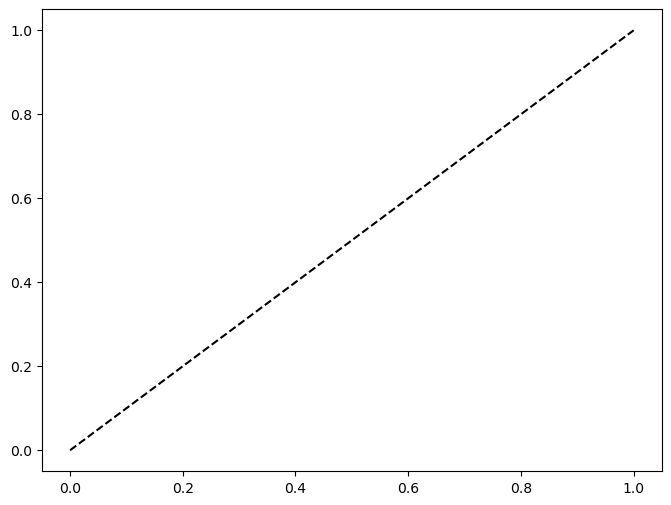

In [7]:
def plot_lorenz(y_true, y_pred, label, ax, color):
    """
    Plots the Lorenz curve and computes risk concentration across policies.
    
    What this function does:
        Ranks validation policies in descending order of predicted claim frequency
        and plots the cumulative percentage of actual claims captured against the
        cumulative percentage of policies.
        
    Actuarial Purpose:
        Measures risk segmentation and discrimination power. A curve bowing higher
        away from the diagonal 45-degree line (Random Model, Gini=0) demonstrates
        superior ability to separate high-risk drivers from safe drivers.
        
    Returns:
        None (draws curve on specified matplotlib axis).
    """
    df_g = pd.DataFrame({'y': y_true, 'p': y_pred}).sort_values('p', ascending=False)
    cum_pop  = np.linspace(0, 1, len(df_g))
    cum_loss = df_g['y'].cumsum().values / df_g['y'].sum()
    ax.plot(cum_pop, cum_loss, label=label, color=color, linewidth=1.5)

fig, ax = plt.subplots(figsize=(8, 6))
ax.plot([0,1],[0,1],'k--', label='Random (Gini=0)')

plot_lorenz(y_val, pred_pois_val, f'Poisson GLM (Gini={gini_coeff(y_val, pred_pois_val)})', ax, 'steelblue')
plot_lorenz(y_val, pred_nb_val,   f'NegBinomial (Gini={gini_coeff(y_val, pred_nb_val)})',   ax, 'tomato')
if HAS_XGB and pred_xgb_val is not None:
    plot_lorenz(y_val, pred_xgb_val, f'XGBoost (Gini={gini_coeff(y_val, pred_xgb_val)})',   ax, 'green')

ax.set_xlabel('Cumulative % of Policies (ranked by predicted frequency)')
ax.set_ylabel('Cumulative % of Actual Claims')
ax.set_title('Lorenz Curve — Frequency Models')
ax.legend(loc='lower right')
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('../outputs/gini_frequency.png', dpi=120)
plt.show()


## 3.8 — ⭐ YOUR CHOICE: Which model to use?

Look at the comparison table and Lorenz curve above, then set `BEST_FREQ_MODEL` below.

**Guide:**
- If overdispersion is present (Deviance >> n) → prefer **NegBinomial**  
- If AIC/Gini is similar → prefer **Poisson GLM** (interpretable coefficients)  
- If Gini of XGBoost is much higher → use **XGBoost**


In [8]:
# ── YOUR CHOICE ──────────────────────────────────────────────────────────────
BEST_FREQ_MODEL = 'Poisson GLM'   # ← Change to 'NegBinomial' or 'XGBoost'
# ─────────────────────────────────────────────────────────────────────────────

X_full_sm = sm.add_constant(X.to_numpy(dtype=float))
off_full   = np.log(np.clip(exposure, 1e-12, None))

if BEST_FREQ_MODEL == 'Poisson GLM':
    freq_pred_full = pois.predict(X_full_sm, offset=off_full)
    save_model = pois;   is_glm = True
elif BEST_FREQ_MODEL == 'NegBinomial':
    freq_pred_full = nb.predict(X_full_sm, offset=off_full)
    save_model = nb;     is_glm = True
else:
    freq_pred_full = xgb.predict(X)
    save_model = xgb;   is_glm = False

df['Freq_Pred'] = freq_pred_full
df.to_parquet('../outputs/df_with_freq.parquet', index=False)

with open('../outputs/freq_model.pkl','wb') as f:
    pickle.dump({'model': save_model, 'model_name': BEST_FREQ_MODEL,
                 'features': FEATURE_COLS, 'is_glm': is_glm}, f)

freq_results = compare_df.to_dict()
freq_results['best_model'] = BEST_FREQ_MODEL
with open('../outputs/frequency_results.json','w') as f:
    json.dump(freq_results, f, indent=2)

print(f'✅ Best frequency model saved: {BEST_FREQ_MODEL}')
print(f'✅ outputs/freq_model.pkl')
print(f'✅ outputs/df_with_freq.parquet')

✅ Best frequency model saved: Poisson GLM
✅ outputs/freq_model.pkl
✅ outputs/df_with_freq.parquet
